# Visual-Only Experiment (Clean, No-Leakage)
This notebook is cleaned and organized for the **visual-only MobileNet** experiment using the team’s `dataset_loader.py` and `augmentation.py`.

Key guarantees:
- **No group/video leakage** (group-level split with stratification)
- **Consistent loaders** (train/val/test all have both classes)
- Model returns: `out_1..out_5, out.squeeze()` for late fusion later


## 1) Setup & Mount Drive


In [ ]:
!pip install -q augly librosa

import os, sys, re, random
import google.colab.drive as drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

import torch
import numpy as np
from PIL import Image
import librosa

# Fix for augly/torchaudio compatibility (Python 3.12 / torchaudio 2.x)
import torchaudio

class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        return tensor, sample_rate

if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 973.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 13.2 MB/s eta 0:00:00
Mounted at /content/drive


## 2) Clone Team Repo (once per runtime)


In [ ]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026


Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 73 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 631.49 KiB | 7.70 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/Final-year-project-2026


## 3) Build Datasets (team code)


In [ ]:
from dataset_loader import DroneFusionDataset, get_loader
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

class Args:
    dataset_dir = "/content/drive/MyDrive/Senior Project"
    batch_size = 4
    crop_size = 122  # for now; set to 112 later to match the paper
args = Args()

audio_root = os.path.join(args.dataset_dir, "Audio")
video_root = os.path.join(args.dataset_dir, "Video")
rf_root    = os.path.join(args.dataset_dir, "RF_Spectrograms")

train_transform = {
    "audio": get_audio_transform(args, is_training=True, feature_type="mfcc"),
    "video": get_img_transform(args, is_training=True, augment=False),
    "rf":    get_rf_transform(args, is_training=True, augment=True),
}
val_transform = {
    "audio": get_audio_transform(args, is_training=False, feature_type="mfcc"),
    "video": get_img_transform(args, is_training=False, augment=True),
    "rf":    get_rf_transform(args, is_training=False, augment=True),
}
test_transform = {
    "audio": get_audio_transform(args, is_training=False, feature_type="mfcc"),
    "video": get_img_transform(args, is_training=False, augment=True),
    "rf":    get_rf_transform(args, is_training=False, augment=False),
}

train_dataset = DroneFusionDataset(audio_root+"/Train", video_root+"/Train", rf_root+"/Train",
                                  "Train", train_transform, audio_feature_type="mfcc", audio_sr=44100)

val_dataset   = DroneFusionDataset(audio_root+"/Validation", video_root+"/Validation", rf_root+"/Validation",
                                  "Validation", val_transform, audio_feature_type="mfcc", audio_sr=44100)

test_dataset  = DroneFusionDataset(audio_root+"/Test", video_root+"/Test", rf_root+"/Test",
                                  "Test", test_transform, audio_feature_type="mfcc", audio_sr=44100)

print("Raw folder splits:")
print("  Train:", len(train_dataset.samples))
print("  Val  :", len(val_dataset.samples))
print("  Test :", len(test_dataset.samples))

# One batch shape check (raw split, before clean split)
tmp_loader = get_loader(train_dataset, batch_size=args.batch_size, is_train=True)
a, v, r, y = next(iter(tmp_loader))
print("Batch shapes -> audio:", getattr(a, "shape", None), "| video:", v.shape, "| rf:", getattr(r, "shape", None), "| y:", y.shape)


Raw folder splits:
  Train: 8480
  Val  : 1280
  Test : 1320
Batch shapes -> audio: torch.Size([4, 1, 40, 40]) | video: torch.Size([4, 7, 3, 122, 122]) | rf: torch.Size([4, 1, 3, 122, 122]) | y: torch.Size([4])


## 4) Clean Split (Group-level + Stratified, No Leakage)
We rebuild train/val/test splits **by group/video id** so the same underlying video does not appear in multiple splits.


In [ ]:
from copy import deepcopy

def extract_group_id(sample):
    # Use first video frame path to identify source video/segment group
    vp = sample["video_frame_paths"][0]
    m_drone = re.search(r"/(Drone_\d+)/", vp)
    m_vid = re.search(r"/(\d+)_frame_", vp)
    drone_id = m_drone.group(1) if m_drone else "BG"
    vid_id = m_vid.group(1) if m_vid else "UNK"
    return f"{drone_id}_vid{vid_id}"

# Collect all samples across the three folder splits
all_samples = train_dataset.samples + val_dataset.samples + test_dataset.samples
print("All samples:", len(all_samples))

# Group by group_id
groups = {}
for s in all_samples:
    gid = extract_group_id(s)
    groups.setdefault(gid, []).append(s)

# Determine group label (majority vote as safety)
group_label = {}
for gid, items in groups.items():
    labels = [it["label"] for it in items]
    group_label[gid] = 1 if sum(labels) >= (len(labels)/2) else 0

gids_0 = [gid for gid in groups.keys() if group_label[gid] == 0]
gids_1 = [gid for gid in groups.keys() if group_label[gid] == 1]

random.shuffle(gids_0)
random.shuffle(gids_1)

def split_list(lst, train_ratio=0.8, val_ratio=0.1):
    n = len(lst)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)
    train = lst[:n_train]
    val   = lst[n_train:n_train+n_val]
    test  = lst[n_train+n_val:]
    return set(train), set(val), set(test)

train0, val0, test0 = split_list(gids_0)
train1, val1, test1 = split_list(gids_1)

train_gids = train0 | train1
val_gids   = val0   | val1
test_gids  = test0  | test1

train_samples_clean = [s for gid in train_gids for s in groups[gid]]
val_samples_clean   = [s for gid in val_gids   for s in groups[gid]]
test_samples_clean  = [s for gid in test_gids  for s in groups[gid]]

def count_labels(samples, name):
    c0 = sum(1 for s in samples if s["label"] == 0)
    c1 = sum(1 for s in samples if s["label"] == 1)
    print(f"{name}: total={len(samples)} | 0={c0} | 1={c1}")

count_labels(train_samples_clean, "TRAIN_CLEAN")
count_labels(val_samples_clean,   "VAL_CLEAN")
count_labels(test_samples_clean,  "TEST_CLEAN")

train_dataset_clean = deepcopy(train_dataset)
val_dataset_clean   = deepcopy(val_dataset)
test_dataset_clean  = deepcopy(test_dataset)

train_dataset_clean.samples = train_samples_clean
val_dataset_clean.samples   = val_samples_clean
test_dataset_clean.samples  = test_samples_clean

# Overlap check
train_ids = set(extract_group_id(s) for s in train_dataset_clean.samples)
val_ids   = set(extract_group_id(s) for s in val_dataset_clean.samples)
test_ids  = set(extract_group_id(s) for s in test_dataset_clean.samples)

print("Overlap train∩val :", len(train_ids & val_ids))
print("Overlap train∩test:", len(train_ids & test_ids))
print("Overlap val∩test  :", len(val_ids & test_ids))


All samples: 11080
TRAIN_CLEAN: total=8840 | 0=3840 | 1=5000
VAL_CLEAN: total=1080 | 0=360 | 1=720
TEST_CLEAN: total=1160 | 0=520 | 1=640
Overlap train∩val : 0
Overlap train∩test: 0
Overlap val∩test  : 0


## 5) DataLoaders (clean split)


In [ ]:
train_loader = get_loader(train_dataset_clean, batch_size=args.batch_size, is_train=True)
val_loader   = get_loader(val_dataset_clean,   batch_size=args.batch_size, is_train=False)
test_loader  = get_loader(test_dataset_clean,  batch_size=args.batch_size, is_train=False)

a, v, r, y = next(iter(train_loader))
print("Clean batch shapes -> video:", v.shape, "| y:", y.shape, "| y unique:", torch.unique(y))


Clean batch shapes -> video: torch.Size([4, 7, 3, 122, 122]) | y: torch.Size([4]) | y unique: tensor([0, 1])


## 6) Visual MobileNet (authors-style output for late fusion)


In [ ]:
import torch.nn as nn
import torch

class ConvBNReLU3D(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(in_planes, out_planes, kernel_size=kernel_size,
                              stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm3d(out_planes)
        self.relu = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class Visual_MobileNet(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv1 = ConvBNReLU3D(3, 32, stride=2)
        self.conv_blocks = nn.Sequential(
            ConvBNReLU3D(32, 64, stride=2),
            ConvBNReLU3D(64, 128, stride=2),
            ConvBNReLU3D(128, 128),
            ConvBNReLU3D(128, 256, stride=2),
            ConvBNReLU3D(256, 256),
            ConvBNReLU3D(256, 512, stride=2),
            *[ConvBNReLU3D(512, 512) for _ in range(5)],
            ConvBNReLU3D(512, 1024, stride=2),
            ConvBNReLU3D(1024, 1024),
        )
        self.avg_pool = nn.AdaptiveAvgPool3d(1)

        # NOTE: This matches the feature map we expose as out_5 (256 channels in our staged outputs below)
        self.fc = nn.Sequential(
            nn.Linear(256, n_classes - 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, T, C, H, W) -> (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)

        x = self.conv1(x)

        out_1 = self.conv_blocks[0](x)
        out_2 = self.conv_blocks[1](out_1)
        out_3 = self.conv_blocks[2](out_2)
        out_4 = self.conv_blocks[3](out_3)
        out_5 = self.conv_blocks[4](out_4)

        x = self.avg_pool(out_5)
        x = torch.flatten(x, 1)
        out = self.fc(x)

        return out_1, out_2, out_3, out_4, out_5, out.squeeze()


## 7) Device & Forward Sanity Check


In [ ]:
device = torch.device("cpu")  # switch to cuda later when stable
model = Visual_MobileNet(n_classes=2).to(device)
print("Using device:", device)

audio, video, rf, label = next(iter(train_loader))
print("Input video:", video.shape, "| label:", label.shape, "| label unique:", torch.unique(label))

video = video.to(device)
with torch.no_grad():
    out_1, out_2, out_3, out_4, out_5, out = model(video)

print("out_1:", out_1.shape)
print("out_5:", out_5.shape)
print("out:", out.shape)


Using device: cpu
Input video: torch.Size([4, 7, 3, 122, 122]) | label: torch.Size([4]) | label unique: tensor([0, 1])
out_1: torch.Size([4, 64, 2, 31, 31])
out_5: torch.Size([4, 256, 1, 8, 8])
out: torch.Size([4])


## 8) Sanity Training (1 epoch) + Metrics
- No label flip
- BCELoss (since model outputs probabilities)
- We report macro F1 + confusion matrix


In [ ]:
from torch.utils.data import DataLoader

val_eval_loader = DataLoader(val_dataset_clean, batch_size=args.batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_eval_loader = DataLoader(test_dataset_clean, batch_size=args.batch_size, shuffle=True, num_workers=0, pin_memory=False)

In [ ]:
print("VAL clean labels:", sum(s["label"]==0 for s in val_dataset_clean.samples), sum(s["label"]==1 for s in val_dataset_clean.samples))
print("TEST clean labels:", sum(s["label"]==0 for s in test_dataset_clean.samples), sum(s["label"]==1 for s in test_dataset_clean.samples))

VAL clean labels: 360 720
TEST clean labels: 520 640


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
import torch.nn as nn
import torch
import numpy as np

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def eval_metrics(loader, max_batches=50):
    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for i, (audio, video, rf, label) in enumerate(loader):
            if i >= max_batches:
                break

            video = video.to(device)
            y = label.float().to(device)

            *_, out = model(video)  # out is prob (sigmoid)
            all_p.extend(out.detach().cpu().numpy().tolist())
            all_y.extend(y.detach().cpu().numpy().tolist())

    all_y = np.array(all_y).astype(int)
    all_p = np.array(all_p)
    pred = (all_p >= 0.5).astype(int)

    # Always force 2x2 CM even if one label appears in subset
    cm = confusion_matrix(all_y, pred, labels=[0, 1])

    f1_pos = f1_score(all_y, pred, labels=[1], average="binary", zero_division=0)
    f1_macro = f1_score(all_y, pred, labels=[0,1], average="macro", zero_division=0)

    pos_rate = float(pred.mean())
    true_pos_rate = float(all_y.mean())

    # Debug mix
    y0 = int((all_y == 0).sum())
    y1 = int((all_y == 1).sum())

    return {
        "cm": cm,
        "f1_pos": f1_pos,
        "f1_macro": f1_macro,
        "pos_rate": pos_rate,
        "true_pos_rate": true_pos_rate,
        "y0": y0,
        "y1": y1
    }

EPOCHS = 1

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n = 0

    for i, (audio, video, rf, label) in enumerate(train_loader):
        video = video.to(device)
        y = label.float().to(device)

        optimizer.zero_grad(set_to_none=True)
        *_, out = model(video)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        n += bs

        if (i + 1) % 20 == 0:
            print(f"Epoch {epoch} | Batch {i+1} | Loss: {loss.item():.4f}")
        if i >= 150:
            break

    train_loss = total_loss / max(1, n)
    m = eval_metrics(val_eval_loader, max_batches=50)

    print(f"\nEpoch {epoch} DONE")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"[Val] pos_rate={m['pos_rate']:.3f} | true_pos_rate={m['true_pos_rate']:.3f}")
    print(f"[Val] F1_pos={m['f1_pos']:.4f} | F1_macro={m['f1_macro']:.4f}")
    print(f"[Val mix] y0={m['y0']} | y1={m['y1']}")
    print("Confusion Matrix:\n", m["cm"])


Epoch 1 | Batch 20 | Loss: 0.3078
Epoch 1 | Batch 40 | Loss: 0.6140
Epoch 1 | Batch 60 | Loss: 0.2191
Epoch 1 | Batch 80 | Loss: 0.1688
Epoch 1 | Batch 100 | Loss: 0.3834
Epoch 1 | Batch 120 | Loss: 1.0251
Epoch 1 | Batch 140 | Loss: 0.1126

Epoch 1 DONE
Train Loss: 0.3123
[Val] pos_rate=0.655 | true_pos_rate=0.655
[Val] F1_pos=1.0000 | F1_macro=1.0000
[Val mix] y0=69 | y1=131
Confusion Matrix:
 [[ 69   0]
 [  0 131]]


## 9) Full Evaluation (VAL + TEST)
This section runs full evaluation on the clean validation and test sets and reports:
- Accuracy
- Precision / Recall / F1 (macro + positive class)
- Confusion matrices


=== VAL_FULL Metrics ===
Accuracy: 1.0000
Macro Precision/Recall/F1: 1.0000 / 1.0000 / 1.0000
Pos(1) Precision/Recall/F1: 1.0000 / 1.0000 / 1.0000
Confusion Matrix:
 [[360   0]
 [  0 720]]

VAL_FULL Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       360
           1     1.0000    1.0000    1.0000       720

    accuracy                         1.0000      1080
   macro avg     1.0000    1.0000    1.0000      1080
weighted avg     1.0000    1.0000    1.0000      1080


=== TEST_FULL Metrics ===
Accuracy: 0.9655
Macro Precision/Recall/F1: 0.9706 / 0.9615 / 0.9648
Pos(1) Precision/Recall/F1: 0.9412 / 1.0000 / 0.9697
Confusion Matrix:
 [[480  40]
 [  0 640]]

TEST_FULL Report:
               precision    recall  f1-score   support

           0     1.0000    0.9231    0.9600       520
           1     0.9412    1.0000    0.9697       640

    accuracy                         0.9655      1160
   macro avg     0.9706    0.9615   

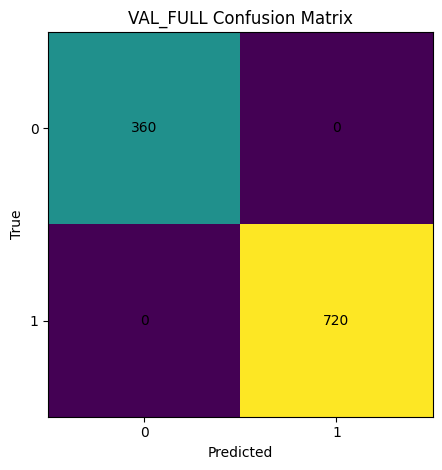

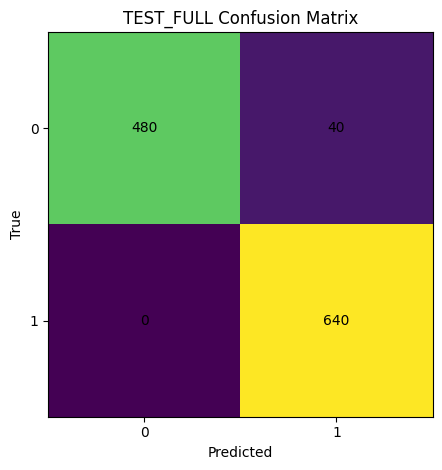

In [ ]:
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch

def eval_full_metrics(loader, threshold=0.5):
    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for audio, video, rf, label in loader:
            video = video.to(device)
            y = label.float().to(device)

            *_, out = model(video)  # model already outputs probabilities
            out_np = out.detach().cpu().view(-1).numpy()
            y_np   = y.detach().cpu().view(-1).numpy()

            all_p.extend(out_np.tolist())
            all_y.extend(y_np.tolist())

    y_true = np.array(all_y).astype(int)
    y_prob = np.array(all_p)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_pos": precision_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
        "y_true": y_true,
        "y_pred": y_pred,
    }
    return metrics

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.tight_layout()
    plt.show()

val_full_loader  = DataLoader(val_dataset_clean,  batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
test_full_loader = DataLoader(test_dataset_clean, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

val_m = eval_full_metrics(val_full_loader, threshold=0.5)
test_m = eval_full_metrics(test_full_loader, threshold=0.5)

print("=== VAL_FULL Metrics ===")
print(f"Accuracy: {val_m['acc']:.4f}")
print(f"Macro Precision/Recall/F1: {val_m['precision_macro']:.4f} / {val_m['recall_macro']:.4f} / {val_m['f1_macro']:.4f}")
print(f"Pos(1) Precision/Recall/F1: {val_m['precision_pos']:.4f} / {val_m['recall_pos']:.4f} / {val_m['f1_pos']:.4f}")
print("Confusion Matrix:\n", val_m["cm"])
print("\nVAL_FULL Report:\n", classification_report(val_m["y_true"], val_m["y_pred"], digits=4, zero_division=0))

print("\n=== TEST_FULL Metrics ===")
print(f"Accuracy: {test_m['acc']:.4f}")
print(f"Macro Precision/Recall/F1: {test_m['precision_macro']:.4f} / {test_m['recall_macro']:.4f} / {test_m['f1_macro']:.4f}")
print(f"Pos(1) Precision/Recall/F1: {test_m['precision_pos']:.4f} / {test_m['recall_pos']:.4f} / {test_m['f1_pos']:.4f}")
print("Confusion Matrix:\n", test_m["cm"])
print("\nTEST_FULL Report:\n", classification_report(test_m["y_true"], test_m["y_pred"], digits=4, zero_division=0))

plot_confusion_matrix(val_m["cm"], "VAL_FULL Confusion Matrix")
plot_confusion_matrix(test_m["cm"], "TEST_FULL Confusion Matrix")


## 10) Optional: Multi-Epoch Baseline Training (Lightweight)
This cell is intentionally lightweight so it runs reliably.
- Partial shuffled validation each epoch
- Best checkpoint saved by validation macro F1
- Training curves at the end


Epoch 1 | Batch 20 | Loss: 0.6505
Epoch 1 | Batch 40 | Loss: 0.3703
Epoch 1 | Batch 60 | Loss: 0.2237
Epoch 1 | Batch 80 | Loss: 0.1429
Epoch 1 | Batch 100 | Loss: 0.2110
Epoch 1 | Batch 120 | Loss: 0.0880
Epoch 1 | Batch 140 | Loss: 0.5153

Epoch 01 DONE | train_loss=0.3684 | val_acc=1.0000 | val_f1_macro=1.0000 | elapsed=3704.9s
Saved best checkpoint: visual_mobilenet_baseline_best.pt | best_val_f1_macro= 1.0
Epoch 2 | Batch 20 | Loss: 0.3327
Epoch 2 | Batch 40 | Loss: 0.0886
Epoch 2 | Batch 60 | Loss: 0.2044
Epoch 2 | Batch 80 | Loss: 0.0536
Epoch 2 | Batch 100 | Loss: 0.0485
Epoch 2 | Batch 120 | Loss: 0.0573
Epoch 2 | Batch 140 | Loss: 0.0396

Epoch 02 DONE | train_loss=0.2053 | val_acc=1.0000 | val_f1_macro=1.0000 | elapsed=3484.1s
Epoch 3 | Batch 20 | Loss: 0.1577
Epoch 3 | Batch 40 | Loss: 0.0522
Epoch 3 | Batch 60 | Loss: 0.0754
Epoch 3 | Batch 80 | Loss: 0.0327
Epoch 3 | Batch 100 | Loss: 0.0643
Epoch 3 | Batch 120 | Loss: 0.0762
Epoch 3 | Batch 140 | Loss: 0.3084

Epoch 03 D

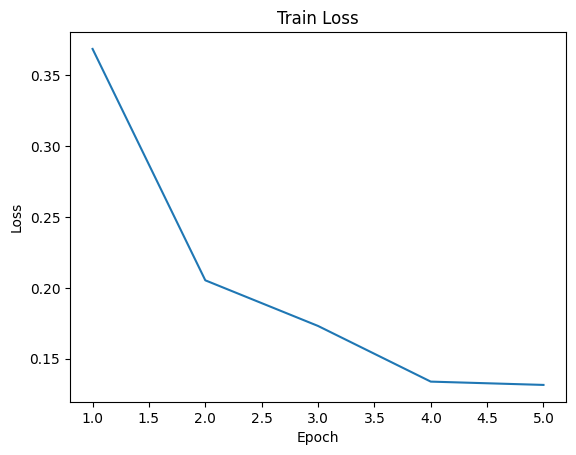

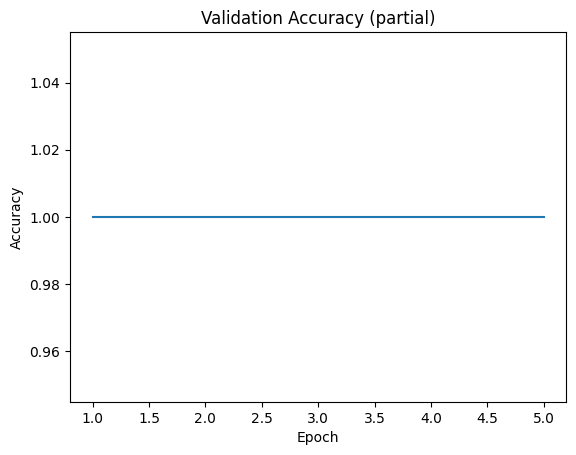

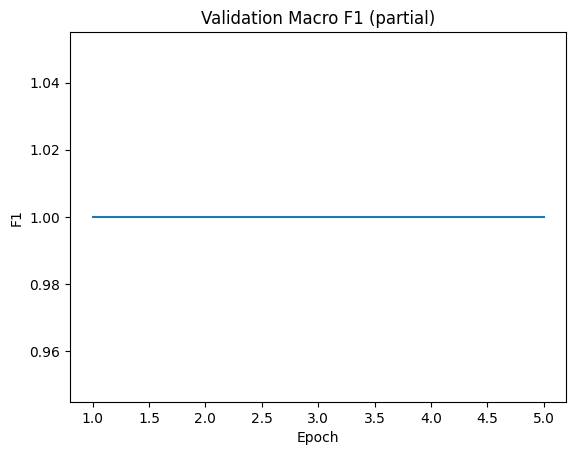

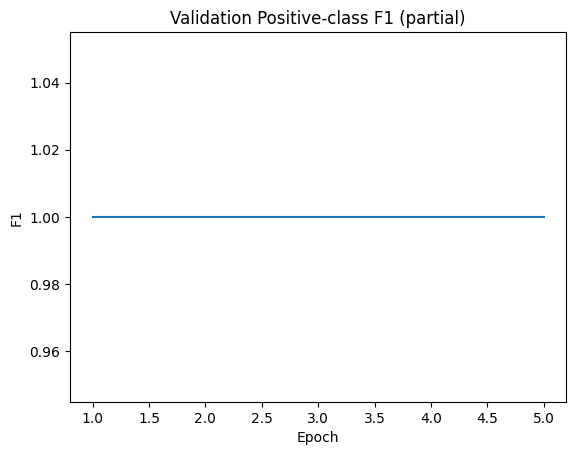

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

# Reinitialize model if you want a fresh run
model = Visual_MobileNet(n_classes=2).to(device)

EPOCHS = 5
LR = 1e-4
SAVE_BEST = True
BEST_PATH = "visual_mobilenet_baseline_best.pt"

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss()

# Fast shuffled partial validation loader
val_eval_loader = DataLoader(
    val_dataset_clean,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

history = {
    "train_loss": [],
    "val_acc": [],
    "val_f1_macro": [],
    "val_f1_pos": []
}

best_f1 = -1.0

def eval_partial_metrics(loader, max_batches=50, threshold=0.5):
    model.eval()
    all_y, all_p = [], []

    with torch.no_grad():
        for i, (audio, video, rf, label) in enumerate(loader):
            if i >= max_batches:
                break

            video = video.to(device)
            y = label.float().to(device)

            *_, out = model(video)
            out_np = out.detach().cpu().view(-1).numpy()
            y_np   = y.detach().cpu().view(-1).numpy()

            all_p.extend(out_np.tolist())
            all_y.extend(y_np.tolist())

    all_y = np.array(all_y).astype(int)
    all_p = np.array(all_p)
    all_pred = (all_p >= threshold).astype(int)

    acc = (all_pred == all_y).mean()
    f1_macro = f1_score(all_y, all_pred, average="macro", zero_division=0)
    f1_pos = f1_score(all_y, all_pred, pos_label=1, average="binary", zero_division=0)

    return {
        "acc": acc,
        "f1_macro": f1_macro,
        "f1_pos": f1_pos
    }

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n = 0
    t0 = time.time()

    for i, (audio, video, rf, label) in enumerate(train_loader):
        video = video.to(device)
        y = label.float().to(device)

        optimizer.zero_grad(set_to_none=True)
        *_, out = model(video)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        n += bs

        if (i + 1) % 20 == 0:
            print(f"Epoch {epoch} | Batch {i+1} | Loss: {loss.item():.4f}")

        # keep optional cell lightweight
        if i >= 150:
            break

    train_loss = total_loss / max(1, n)
    history["train_loss"].append(train_loss)

    vm = eval_partial_metrics(val_eval_loader, max_batches=50, threshold=0.5)
    history["val_acc"].append(vm["acc"])
    history["val_f1_macro"].append(vm["f1_macro"])
    history["val_f1_pos"].append(vm["f1_pos"])

    print(f"\nEpoch {epoch:02d} DONE | train_loss={train_loss:.4f} | "
          f"val_acc={vm['acc']:.4f} | val_f1_macro={vm['f1_macro']:.4f} | "
          f"elapsed={time.time()-t0:.1f}s")

    if SAVE_BEST and vm["f1_macro"] > best_f1:
        best_f1 = vm["f1_macro"]
        torch.save({
            "model_state": model.state_dict(),
            "best_val_f1_macro": best_f1,
            "epoch": epoch,
            "lr": LR
        }, BEST_PATH)
        print("Saved best checkpoint:", BEST_PATH, "| best_val_f1_macro=", best_f1)

epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs_axis, history["train_loss"])
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(epochs_axis, history["val_acc"])
plt.title("Validation Accuracy (partial)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(epochs_axis, history["val_f1_macro"])
plt.title("Validation Macro F1 (partial)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.show()

plt.figure()
plt.plot(epochs_axis, history["val_f1_pos"])
plt.title("Validation Positive-class F1 (partial)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.show()
